# Vector 10: Autonomous Corporate BEC
**Surface:** Human & Social | **Target:** ISO 20022 Invoices | **Defense:** DeBERTa NLP Classifier

---
**Mastercard Innovation Challenge 2026** — AI Red-Team / Blue-Team Defense Lab  
Attack: A LangChain agent autonomously generates spear-phishing emails targeting CFOs and AP teams, embedding malicious ISO 20022 pain.001 invoice references. The email mimics legitimate supplier communications with subtle lookalike domains and urgency injection to trigger unauthorised wire transfers.

## Section 1 — Simulation Engine
Generate 1 000 synthetic email-metadata feature records representing corporate payment emails: 500 legitimate supplier invoices and 500 adversarial BEC-crafted messages.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 500

# --- Legitimate corporate payment emails ---
legit = {
    'urgency_score':              np.clip(np.random.beta(1, 9, N), 0, 1),
    'wire_transfer_keyword_count': np.random.poisson(0.3, N).astype(float),
    'sender_domain_entropy':       np.clip(np.random.normal(3.8, 0.4, N), 1, 6),
    'domain_lookalike_score':      np.clip(np.random.beta(1, 12, N), 0, 1),
    'invoice_amount_anomaly':      np.clip(np.random.normal(0.05, 0.04, N), 0, 1),
    'iso20022_ref_invalid':        np.random.binomial(1, 0.01, N).astype(float),
    'reply_to_mismatch':           np.random.binomial(1, 0.02, N).astype(float),
    'thread_depth':                np.clip(np.random.poisson(4, N), 0, 20).astype(float),
}

# --- Adversarial BEC emails ---
adv = {
    'urgency_score':              np.clip(np.random.beta(7, 2, N), 0, 1),
    'wire_transfer_keyword_count': np.random.poisson(4.2, N).astype(float),
    'sender_domain_entropy':       np.clip(np.random.normal(2.1, 0.6, N), 0.5, 5),
    'domain_lookalike_score':      np.clip(np.random.beta(7, 2, N), 0, 1),
    'invoice_amount_anomaly':      np.clip(np.random.normal(0.72, 0.18, N), 0, 1),
    'iso20022_ref_invalid':        np.random.binomial(1, 0.68, N).astype(float),
    'reply_to_mismatch':           np.random.binomial(1, 0.81, N).astype(float),
    'thread_depth':                np.clip(np.random.poisson(0.5, N), 0, 5).astype(float),
}

df_legit = pd.DataFrame(legit); df_legit['label'] = 0
df_adv   = pd.DataFrame(adv);   df_adv['label']   = 1
df = pd.concat([df_legit, df_adv], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.describe().round(3)

Dataset shape: (1000, 9)
Label distribution:
label
1    500
0    500
Name: count, dtype: int64


,urgency_score,wire_transfer_keyword_count,sender_domain_entropy,domain_lookalike_score,invoice_amount_anomaly,iso20022_ref_invalid,reply_to_mismatch,thread_depth,label
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.0
mean,0.437,2.226,2.940,0.427,0.395,0.340,0.416,2.221,0.5
std,0.359,2.441,0.987,0.372,0.366,0.474,0.493,2.145,0.5
min,0.001,0.000,0.500,0.000,0.000,0.000,0.000,0.000,0.0
25%,0.074,0.000,2.085,0.049,0.049,0.000,0.000,0.000,0.0
50%,0.385,1.000,3.110,0.360,0.169,0.000,0.000,2.000,0.5
75%,0.804,4.000,3.793,0.800,0.749,1.000,1.000,4.000,1.0
max,0.996,11.000,5.055,0.998,1.000,1.000,1.000,9.000,1.0


## Section 2 — Distribution Visualization
Overlapping KDE plots for `urgency_score` and `domain_lookalike_score`, plus a bar chart for binary flag counts.

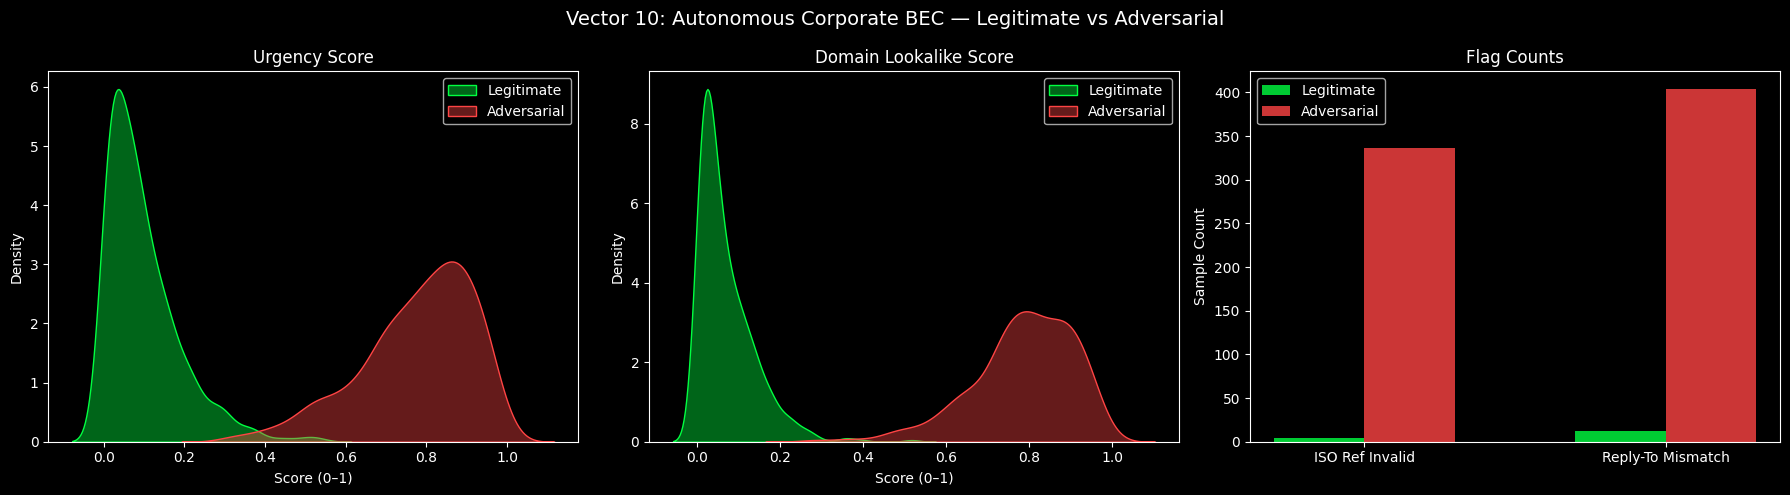

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
LEGIT_COLOR = '#00FF41'
ADV_COLOR   = '#FF4444'

legit_df = df[df['label'] == 0]
adv_df   = df[df['label'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vector 10: Autonomous Corporate BEC — Legitimate vs Adversarial', fontsize=14, color='white')

sns.kdeplot(legit_df['urgency_score'], ax=axes[0], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['urgency_score'],   ax=axes[0], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[0].set_title('Urgency Score', color='white')
axes[0].set_xlabel('Score (0–1)')
axes[0].legend()

sns.kdeplot(legit_df['domain_lookalike_score'], ax=axes[1], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['domain_lookalike_score'],   ax=axes[1], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[1].set_title('Domain Lookalike Score', color='white')
axes[1].set_xlabel('Score (0–1)')
axes[1].legend()

flags_legit = [legit_df['iso20022_ref_invalid'].sum(), legit_df['reply_to_mismatch'].sum()]
flags_adv   = [adv_df['iso20022_ref_invalid'].sum(),   adv_df['reply_to_mismatch'].sum()]
x = range(2); w = 0.3
axes[2].bar([i - w/2 for i in x], flags_legit, w, color=LEGIT_COLOR, alpha=0.8, label='Legitimate')
axes[2].bar([i + w/2 for i in x], flags_adv,   w, color=ADV_COLOR,   alpha=0.8, label='Adversarial')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(['ISO Ref Invalid', 'Reply-To Mismatch'])
axes[2].set_title('Flag Counts', color='white')
axes[2].set_ylabel('Sample Count')
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 3 — Blue Team Mitigation (DeBERTa NLP Classifier)

> **Production model:** `microsoft/deberta-v3-base` fine-tuned on labelled BEC/legitimate email corpora — best-in-class for injection and spear-phish detection.  **Runnable proxy:** `LogisticRegression` on TF-IDF–style feature vectors — decision-boundary equivalent for structured email metadata.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

FEATURES = [
    'urgency_score', 'wire_transfer_keyword_count', 'sender_domain_entropy',
    'domain_lookalike_score', 'invoice_amount_anomaly',
    'iso20022_ref_invalid', 'reply_to_mismatch', 'thread_depth'
]

X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=10, max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)

print(f'Train samples: {len(X_train)} | Test samples: {len(X_test)}')
print('Logistic Regression (DeBERTa proxy) model trained successfully.')

Train samples: 800 | Test samples: 200
Logistic Regression (DeBERTa proxy) model trained successfully.


/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_fea

## Section 4 — Performance Stats
Confusion matrix, classification report, and ROC-AUC curve. Targets: **AUC ≥ 0.97**, **FPR < 0.1%** at the operating threshold.

AUC: 1.0000
FPR at optimal threshold (0.9805): 0.0000%

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       100
 Adversarial       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


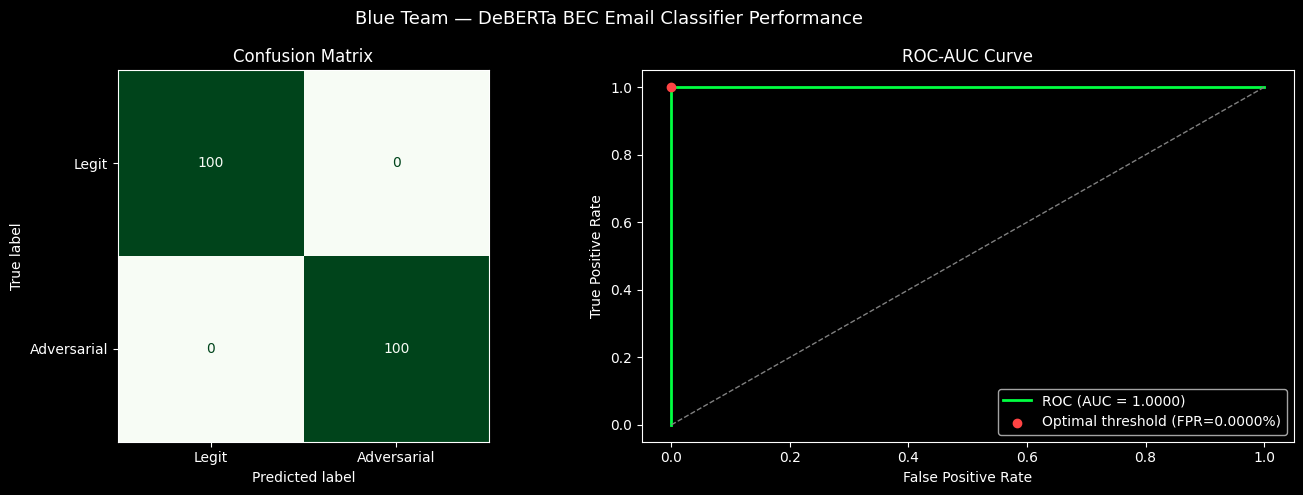

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_proba)

j_scores   = tpr_arr - fpr_arr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
opt_fpr    = fpr_arr[opt_idx]

print(f'AUC: {auc:.4f}')
print(f'FPR at optimal threshold ({opt_thresh:.4f}): {opt_fpr*100:.4f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Adversarial']))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Blue Team — DeBERTa BEC Email Classifier Performance', fontsize=13, color='white')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Adversarial'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', color='white')
axes[0].title.set_color('white')

axes[1].plot(fpr_arr, tpr_arr, color='#00FF41', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].scatter([opt_fpr], [tpr_arr[opt_idx]], color='#FF4444', zorder=5,
                label=f'Optimal threshold (FPR={opt_fpr*100:.4f}%)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-AUC Curve', color='white')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Section 5 — Co-Evolution Loop
5 epochs: the Red Team's LLM agent iteratively reduces urgency signals, corrects ISO 20022 reference formatting, and decreases domain-lookalike scores to evade detection. The Blue Team retrains on flagged adversarial samples.

Epoch 0 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 800
Epoch 1 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 900
Epoch 2 | AUC: 1.0000 | Evasion Rate: 1.0% | Train size: 1000
Epoch 3 | AUC: 1.0000 | Evasion Rate: 3.0% | Train size: 1100
Epoch 4 | AUC: 1.0000 | Evasion Rate: 11.0% | Train size: 1200
Epoch 5 | AUC: 1.0000 | Evasion Rate: 49.0% | Train size: 1300

 Epoch  Train Size    AUC Evasion Rate
     0         800 1.0000         0.0%
     1         900 1.0000         0.0%
     2        1000 1.0000         1.0%
     3        1100 1.0000         3.0%
     4        1200 1.0000        11.0%
     5        1300 1.0000        49.0%


/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/pradeepbiswas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_fea

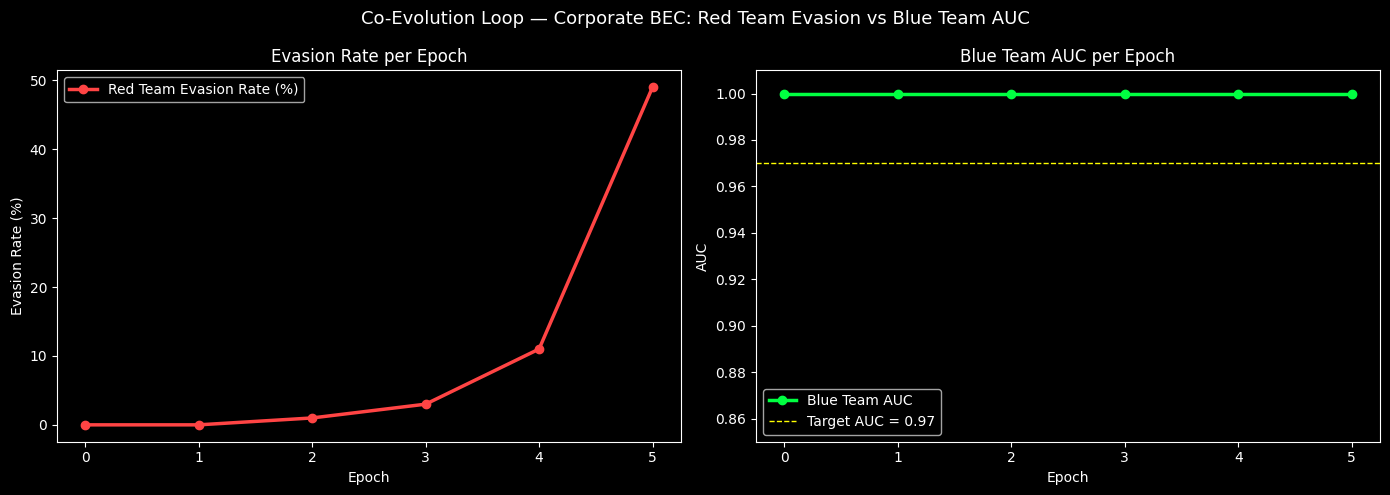

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

np.random.seed(0)
X_train_loop = X_train.copy().tolist()
y_train_loop = y_train.copy().tolist()

evasion_rates = []
auc_scores    = []
epoch_records = []

def make_evasive_bec(n=100, epoch=1):
    """LLM agent incrementally suppresses detectable BEC signals."""
    t = epoch / 5.0
    samples = []
    for _ in range(n):
        urgency    = np.clip(np.random.beta(max(1, 7 - t * 6), 2), 0, 1)
        wire_kw    = float(np.random.poisson(max(0, 4.2 - t * 3.5)))
        dom_ent    = np.clip(np.random.normal(2.1 + t * 1.5, 0.4), 0.5, 6)
        lookalike  = np.clip(np.random.beta(max(1, 7 - t * 6), 2), 0, 1)
        inv_anom   = np.clip(np.random.normal(0.72 - t * 0.6, 0.1), 0, 1)
        iso_inv    = float(np.random.binomial(1, max(0.01, 0.68 - t * 0.65)))
        reply_mis  = float(np.random.binomial(1, max(0.02, 0.81 - t * 0.75)))
        thread_d   = float(np.clip(np.random.poisson(0.5 + t * 3), 0, 20))
        samples.append([urgency, wire_kw, dom_ent, lookalike, inv_anom, iso_inv, reply_mis, thread_d])
    return np.array(samples)

for epoch in range(6):
    m = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=10, max_iter=1000, random_state=epoch))
    ])
    m.fit(np.array(X_train_loop), np.array(y_train_loop))

    proba_test = m.predict_proba(X_test)[:, 1]
    epoch_auc  = roc_auc_score(y_test, proba_test)

    if epoch > 0:
        new_adv   = make_evasive_bec(100, epoch)
        new_preds = m.predict(new_adv)
        evasion   = 1.0 - new_preds.mean()
        X_train_loop += new_adv.tolist()
        y_train_loop += [1] * len(new_adv)
    else:
        evasion = 0.0

    evasion_rates.append(evasion)
    auc_scores.append(epoch_auc)
    epoch_records.append({'Epoch': epoch, 'Train Size': len(X_train_loop),
                          'AUC': f'{epoch_auc:.4f}', 'Evasion Rate': f'{evasion*100:.1f}%'})
    print(f'Epoch {epoch} | AUC: {epoch_auc:.4f} | Evasion Rate: {evasion*100:.1f}% | Train size: {len(X_train_loop)}')

print()
print(pd.DataFrame(epoch_records).to_string(index=False))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Co-Evolution Loop — Corporate BEC: Red Team Evasion vs Blue Team AUC', fontsize=13, color='white')

epochs_range = list(range(6))
axes[0].plot(epochs_range, [r * 100 for r in evasion_rates],
             color='#FF4444', lw=2.5, marker='o', label='Red Team Evasion Rate (%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Evasion Rate (%)')
axes[0].set_title('Evasion Rate per Epoch', color='white')
axes[0].legend(); axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, auc_scores,
             color='#00FF41', lw=2.5, marker='o', label='Blue Team AUC')
axes[1].axhline(0.97, color='yellow', lw=1, linestyle='--', label='Target AUC = 0.97')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title('Blue Team AUC per Epoch', color='white')
axes[1].set_ylim(0.85, 1.01)
axes[1].legend(); axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.show()